(2) Ch8_Q4

***(a) Sketch the tree corresponding to the partition of the predictor space illustrated in the left-hand panel of Figure 8.14. The numbers inside the boxes indicate the mean of Y within each region.***<br>
***(b) Create a diagram similar to the left-hand panel of Figure 8.14, using the tree illustrated in the right-hand panel of the same figure. You should divide up the predictor space into the correct regions, and indicate the mean for each region.***

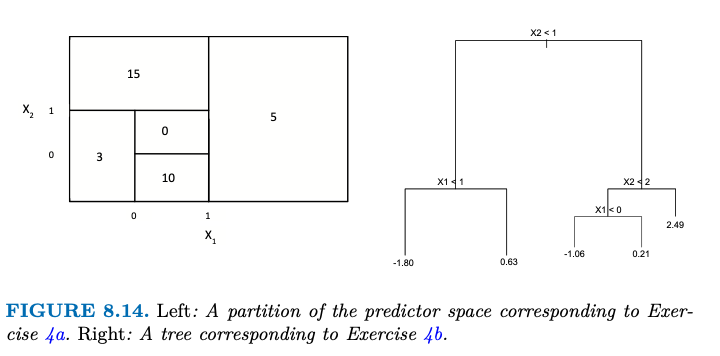

In [6]:
from IPython.display import Image, display

# 直接顯示 PNG
display(Image(filename='tree.png'))

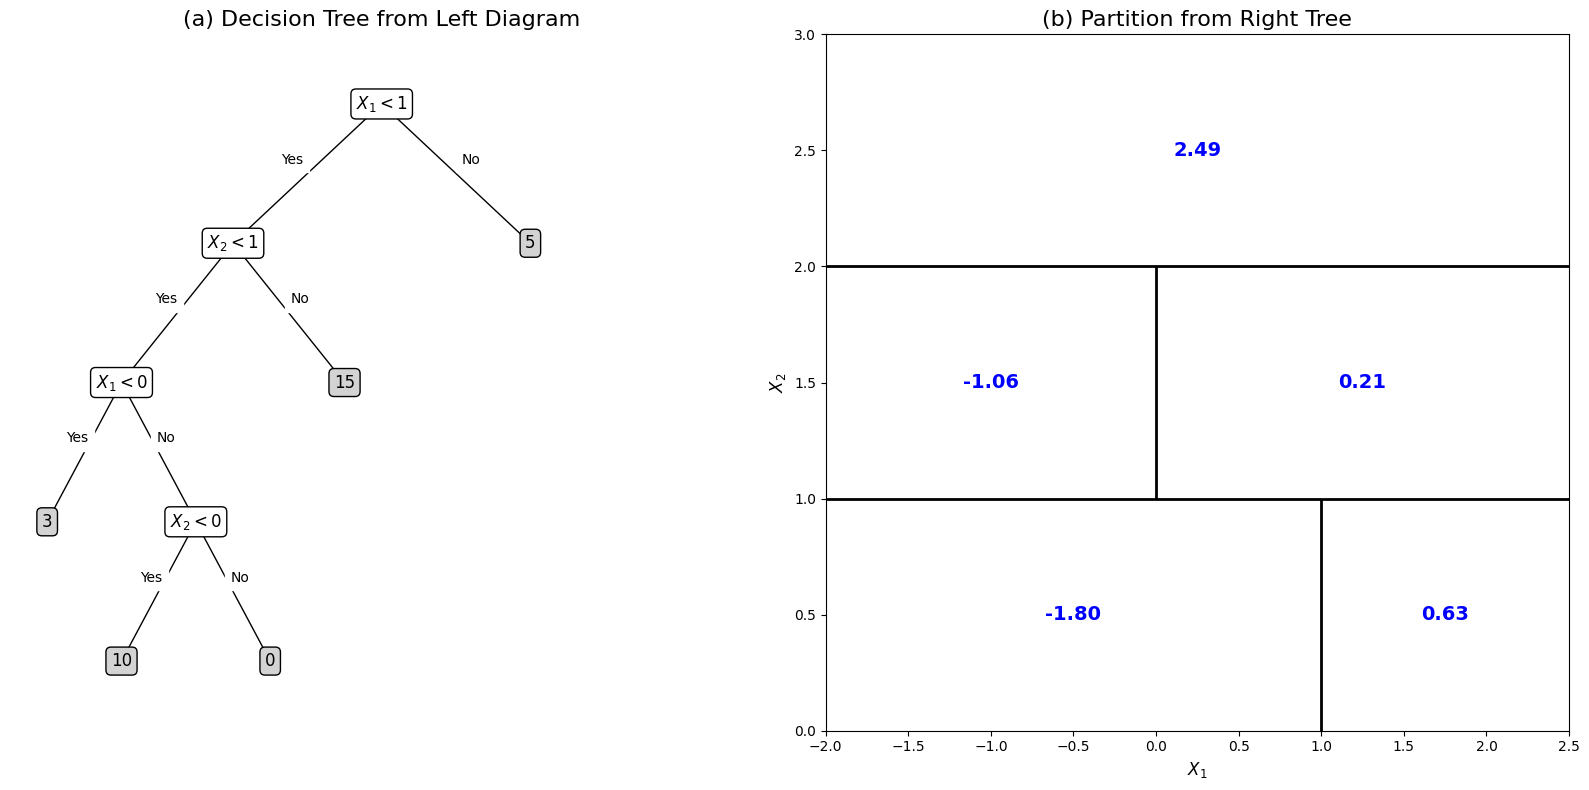

In [11]:
import matplotlib.pyplot as plt

# 1. 設置畫布大小，包含兩個子圖 (1行, 2列)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ==========================================
# Part (a): 繪製決策樹 (Draw on axes[0])
# ==========================================
def draw_tree_on_ax(ax):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off') # 隱藏座標軸
    ax.set_title("(a) Decision Tree from Left Diagram", fontsize=16)

    # 定義節點樣式
    node_box = dict(boxstyle="round,pad=0.3", fc="white", ec="black")
    leaf_box = dict(boxstyle="round,pad=0.3", fc="lightgray", ec="black")
    
    # 輔助函數：畫線和節點
    def connect(p1, p2, label_loc=None, label_txt=""):
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'k-', lw=1)
        if label_loc and label_txt:
            ax.text(label_loc[0], label_loc[1], label_txt, fontsize=10, 
                    ha='center', va='center', backgroundcolor='white')

    def draw_node(pos, text, is_leaf=False):
        style = leaf_box if is_leaf else node_box
        ax.text(pos[0], pos[1], text, ha='center', va='center', fontsize=12, bbox=style)

    # --- 定義節點座標 ---
    root = (5, 9)
    lvl2_left, lvl2_right = (3, 7), (7, 7)
    lvl3_left, lvl3_right = (1.5, 5), (4.5, 5)
    lvl4_left, lvl4_right = (0.5, 3), (2.5, 3)
    lvl5_left, lvl5_right = (1.5, 1), (3.5, 1)

    # --- 繪製連接線 ---
    connect(root, lvl2_left, (3.8, 8.2), "Yes")
    connect(root, lvl2_right, (6.2, 8.2), "No") # X1 >= 1 -> 5
    
    connect(lvl2_left, lvl3_left, (2.1, 6.2), "Yes")
    connect(lvl2_left, lvl3_right, (3.9, 6.2), "No") # X2 >= 1 -> 15
    
    connect(lvl3_left, lvl4_left, (0.9, 4.2), "Yes") # X1 < 0 -> 3
    connect(lvl3_left, lvl4_right, (2.1, 4.2), "No")
    
    connect(lvl4_right, lvl5_left, (1.9, 2.2), "Yes") # X2 < 0 -> 10
    connect(lvl4_right, lvl5_right, (3.1, 2.2), "No") # X2 >= 0 -> 0

    # --- 繪製節點文字 ---
    draw_node(root, r"$X_1 < 1$")
    draw_node(lvl2_left, r"$X_2 < 1$")
    draw_node(lvl2_right, "5", is_leaf=True)
    draw_node(lvl3_left, r"$X_1 < 0$")
    draw_node(lvl3_right, "15", is_leaf=True)
    draw_node(lvl4_left, "3", is_leaf=True)
    draw_node(lvl4_right, r"$X_2 < 0$") 
    draw_node(lvl5_left, "10", is_leaf=True)
    draw_node(lvl5_right, "0", is_leaf=True)

# 執行畫樹函數，傳入第一個子圖 axes[0]
draw_tree_on_ax(axes[0])


# ==========================================
# Part (b): 繪製分區圖 (Draw on axes[1])
# ==========================================
ax2 = axes[1]
ax2.set_title("(b) Partition from Right Tree", fontsize=16)
ax2.set_xlabel(r"$X_1$", fontsize=12)
ax2.set_ylabel(r"$X_2$", fontsize=12)

# 設定顯示範圍
ax2.set_xlim(-2.0, 2.5)
ax2.set_ylim(0.0, 3.0)

# --- 1. 繪製分割線 ---
# Root: X2 < 1 (橫跨全圖)
ax2.hlines(y=1, xmin=-2.0, xmax=2.5, colors='k', linewidth=2)

# Branch Left: X1 < 1 (只在 X2 < 1 的區域)
ax2.vlines(x=1, ymin=0, ymax=1, colors='k', linewidth=2)

# Branch Right Top: X2 < 2 (只在 X2 >= 1 的區域)
ax2.hlines(y=2, xmin=-2.0, xmax=2.5, colors='k', linewidth=2)

# Branch Right Middle: X1 < 0 (只在 1 <= X2 < 2 的區域)
ax2.vlines(x=0, ymin=1, ymax=2, colors='k', linewidth=2)

# --- 2. 標註區域數值 ---
# 字體設定
font_style = {'fontsize': 14, 'ha': 'center', 'va': 'center', 'weight': 'bold', 'color': 'blue'}

ax2.text(-0.5, 0.5, "-1.80", **font_style) # 左下
ax2.text(1.75, 0.5, "0.63", **font_style)  # 右下
ax2.text(0.25, 2.5, "2.49", **font_style)  # 頂部
ax2.text(-1.0, 1.5, "-1.06", **font_style) # 中左
ax2.text(1.25, 1.5, "0.21", **font_style)  # 中右

# ==========================================
# 顯示最終結果
# ==========================================
plt.tight_layout()
plt.show()


### 4(a): 根據左側的區域劃分圖，畫出對應的決策樹
左圖顯示了一個二維特徵空間 ($X_1, X_2$) 被幾條直線切割成了不同的區域。我們需要通過觀察這些切割線的順序來重建決策樹。

**分析步驟：**

*   **第一刀 (Root Split)**：觀察圖中最長的分割線，是垂直線 $X_1 = 1$。
    *   **右側 ($X_1 \ge 1$)**：沒有進一步分割，區域內的預測值為 **5**。
    *   **左側 ($X_1 < 1$)**：還有更多分割，進入下一層。
*   **第二刀**：在 $X_1 < 1$ 的區域內，有一條水平線 $X_2 = 1$ 將其切開。
    *   **上方 ($X_2 \ge 1$)**：沒有進一步分割，預測值為 **15**。
    *   **下方 ($X_2 < 1$)**：還有更多分割，進入下一層。
*   **第三刀**：在左下角的區域 ($X_1 < 1, X_2 < 1$) 內，有一條垂直線 $X_1 = 0$ (即 Y 軸)。
    *   **左側 ($X_1 < 0$)**：預測值為 **3**。
    *   **右側 ($0 \le X_1 < 1$)**：還有分割。
*   **第四刀**：在剩餘的方塊 ($0 \le X_1 < 1, X_2 < 1$) 內，有一條水平線（圖中未標出具體座標，我們假設它在某個位置 $c$，例如 0.5）。
    *   **下方**（假設 $X_2 < 0$）：預測值為 **10**。
    *   **上方**（假設 $X_2 \ge 0$）：預測值為 **0**。

---

### 4(b): 根據右側的決策樹，畫出對應的區域劃分圖
右圖給出了一個已經建立好的樹，我們需要將其翻譯成二維平面圖。

**分析步驟與繪圖描述：**

1.  **根節點分割 ($X_2 < 1$)**：
    *   首先畫一條水平線 $X_2 = 1$，橫跨整個平面。這條線將平面分為**上半部**和**下半部**。

2.  **處理下半部 ($X_2 < 1$, 樹的左分支)**：
    *   樹上顯示下一個分割條件是 $X_1 < 1$。
    *   在 $X_2 < 1$ 的區域內畫一條垂直線 $X_1 = 1$。
    *   這條線左邊 ($X_1 < 1$) 的區域填入值 **-1.80**。
    *   這條線右邊 ($X_1 \ge 1$) 的區域填入值 **0.63**。

3.  **處理上半部 ($X_2 \ge 1$, 樹的右分支)**：
    *   樹上顯示下一個分割條件是 $X_2 < 2$。
    *   在 $X_2 \ge 1$ 的區域內畫一條水平線 $X_2 = 2$。
    *   **最上方區域** ($X_2 \ge 2$)：不再分割，填入值 **2.49**。
    *   **中間區域** ($1 \le X_2 < 2$)：樹上顯示還有一個分割 $X_1 < 0$。
        *   在這個帶狀區域內畫一條垂直線 $X_1 = 0$。
        *   左邊 ($X_1 < 0$) 填入值 **-1.06**。
        *   右邊 ($X_1 \ge 0$) 填入值 **0.21**。

**最終圖形長相描述：**
*   你的圖會有兩條橫線 ($X_2=1, X_2=2$) 和兩條直線段。
*   底部 ($X_2 < 1$) 被 $X_1=1$ 分為左右兩塊。
*   頂部 ($X_2 \ge 2$) 是一整塊長條。
*   中間層 ($1 \le X_2 < 2$) 被 $X_1=0$ 分為左右兩塊。
